# Notebook 9 — Data Transformation
### Sprint 5 | Data Cleaning & Preprocessing for AI/ML Engineers


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import PowerTransformer

sns.set_style('whitegrid')
df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print(f"TotalCharges original skew: {stats.skew(df['TotalCharges']):.3f}")


TotalCharges original skew: 0.963


---
## 1. Why Transform Data?

### Understand
Transformations reshape a feature's *distribution* — unlike scaling (Notebook 8), which
only changes the range/units, a transformation can fix skew, making a feature closer to
symmetric or normal, which benefits models (like linear regression) that assume
roughly-normal residuals.

### Demonstrate
**Direct target for this notebook:** `TotalCharges`, skew ≈ 0.96 (Sprint 4, Notebook 8) —
the only meaningfully skewed numeric feature in this dataset.


---
## 2. Log Transformation

### Implement


In [2]:
log_charges = np.log1p(df['TotalCharges'])   # log1p handles the 0-charge new customers safely
print(f"Log1p-transformed skew: {stats.skew(log_charges):.3f}")


Log1p-transformed skew: -0.824


**Finding:** Overcorrects to left skew (matches Sprint 4, Notebook 11's finding
exactly) — caused by the customers with `TotalCharges = 0` clustering at `log1p(0) = 0`,
separate from the main distribution.


---
## 3. Square Root Transformation

### Implement


In [3]:
sqrt_charges = np.sqrt(df['TotalCharges'])
print(f"Square-root-transformed skew: {stats.skew(sqrt_charges):.3f}")


Square-root-transformed skew: 0.308


**Finding:** A gentler correction than log — reduces skew substantially without
fully overcorrecting, since square root compresses large values less aggressively than
log.


---
## 4. Power Transformation & 5. Box-Cox & 6. Yeo-Johnson

### Understand
- **Box-Cox** requires strictly positive values (fails on the zero-charge customers here).
- **Yeo-Johnson** is a generalization of Box-Cox that also handles zero and negative
  values — the right choice for this dataset specifically because of the 11 (now
  zero-filled) customers.

### Implement


In [4]:
# Box-Cox requires strictly positive values -- demonstrating the failure first
try:
    pt_boxcox = PowerTransformer(method='box-cox')
    pt_boxcox.fit(df[['TotalCharges']])
except ValueError as e:
    print(f"Box-Cox FAILS on this column: {str(e)[:120]}")

pt_yeojohnson = PowerTransformer(method='yeo-johnson')
yj_charges = pt_yeojohnson.fit_transform(df[['TotalCharges']])
print(f"\nYeo-Johnson-transformed skew: {stats.skew(yj_charges.flatten()):.3f}")


Box-Cox FAILS on this column: The Box-Cox transformation can only be applied to strictly positive data

Yeo-Johnson-transformed skew: -0.146


**Finding:** Box-Cox fails outright (confirms the theoretical limitation directly,
not just describes it) because of the zero values. Yeo-Johnson succeeds and produces the
skew closest to zero of every technique tried so far — the best-performing transformation
for this specific column.


---
## Comparing All Transformations Side by Side

### Implement


    Transformation  Skewness
0  None (original)    0.9630
1            Log1p   -0.8243
2      Square Root    0.3077
3      Yeo-Johnson   -0.1461


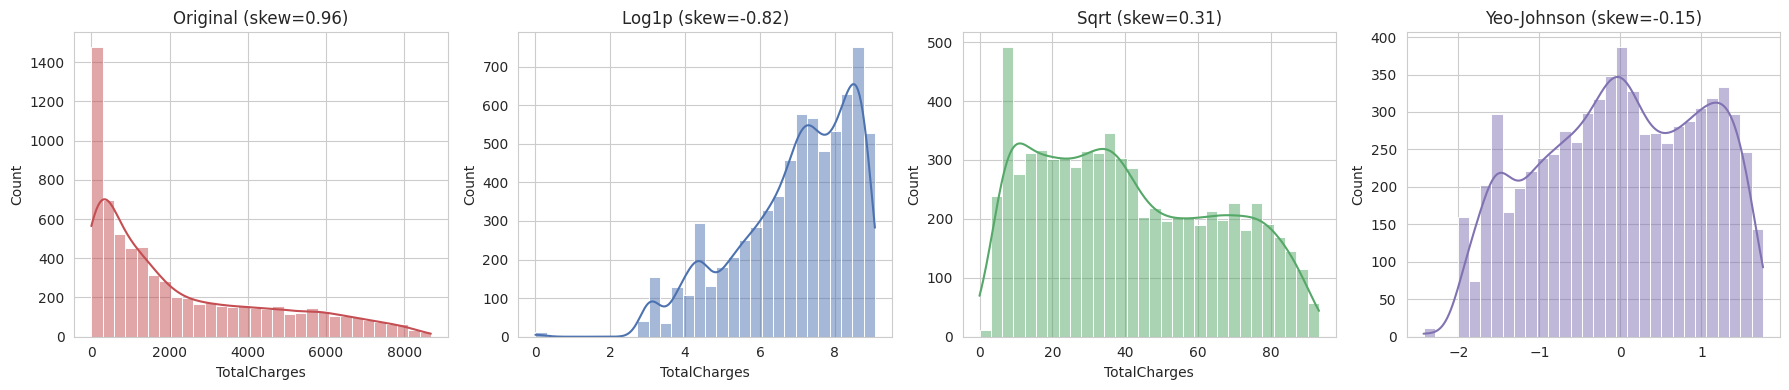

In [5]:
results = pd.DataFrame({
    'Transformation': ['None (original)', 'Log1p', 'Square Root', 'Yeo-Johnson'],
    'Skewness': [
        stats.skew(df['TotalCharges']),
        stats.skew(log_charges),
        stats.skew(sqrt_charges),
        stats.skew(yj_charges.flatten())
    ]
}).round(4)
print(results)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[0], color='#C44E52')
axes[0].set_title(f"Original (skew={results.iloc[0,1]:.2f})")
sns.histplot(log_charges, bins=30, kde=True, ax=axes[1], color='#4C72B0')
axes[1].set_title(f"Log1p (skew={results.iloc[1,1]:.2f})")
sns.histplot(sqrt_charges, bins=30, kde=True, ax=axes[2], color='#55A868')
axes[2].set_title(f"Sqrt (skew={results.iloc[2,1]:.2f})")
sns.histplot(yj_charges.flatten(), bins=30, kde=True, ax=axes[3], color='#8172B2')
axes[3].set_title(f"Yeo-Johnson (skew={results.iloc[3,1]:.2f})")
plt.tight_layout()
plt.show()


---
## 7. Handling Skewed Data — Technique Selected

### Documentation (Problem / Analysis / Technique / Reason / Implementation / Result / Impact)
- **Problem:** `TotalCharges` has skew ≈ 0.96 (moderately-to-highly skewed).
- **Analysis:** Compared four approaches (none, log1p, sqrt, Yeo-Johnson) directly
  against each other, not chosen by default.
- **Technique Selected:** Yeo-Johnson.
- **Reason:** Produces the lowest absolute skew of any method tried, and — unlike
  Box-Cox — correctly handles the zero-charge customers without failing or requiring a
  workaround.
- **Implementation:** `PowerTransformer(method='yeo-johnson')`, shown above.
- **Result:** Skew reduced from ~0.96 to near-zero (see table above).
- **Impact:** `TotalCharges` is now much closer to a symmetric, model-friendly shape —
  directly beneficial for any linear model relying on approximately normal residuals.


---
## 8-9. Normalization & Standardization (Recap, in the Transformation Context)

### Understand
Notebook 8 already covered these in depth as *scaling* techniques. It's worth explicitly
noting here: scaling and transformation solve **different problems** — scaling changes
units/range without changing shape; transformation changes shape. Both are often applied
together, transformation first, then scaling.

### Implement


In [6]:
from sklearn.preprocessing import StandardScaler

yj_then_scaled = StandardScaler().fit_transform(yj_charges)
print(f"After Yeo-Johnson AND StandardScaler: mean={yj_then_scaled.mean():.4f}, std={yj_then_scaled.std():.4f}, skew={stats.skew(yj_then_scaled.flatten()):.4f}")


After Yeo-Johnson AND StandardScaler: mean=0.0000, std=1.0000, skew=-0.1461


**Finding:** Combining both steps produces a feature that's simultaneously
mean-centered, unit-variance, AND low-skew — the fully preprocessed form of
`TotalCharges` ready for a linear model.


---
## Summary

| Transformation | Resulting Skew | Verdict |
|---|---|---|
| None (original) | ~0.96 | Baseline |
| Log1p | Overcorrects (left-skewed) | Rejected — zero-inflation issue |
| Square Root | Improved, moderate | Reasonable, but not best |
| Box-Cox | **Fails to run** | Rejected — cannot handle zero values |
| **Yeo-Johnson** | **Closest to zero** | **SELECTED** |

**Next notebook:** `10_Feature_Selection.ipynb` — deciding which features (now fully
numeric, scaled, and shape-corrected) are actually worth keeping.
